In [61]:
import numpy as np 

import matplotlib.pyplot as plt


from numpy.fft import rfftn, fftfreq, rfftfreq

In [62]:
#crea griglia


In [63]:
#define the grid
L= 1000 # lenght of the grid in Mpc/h
volume = L^3
n_points= 100000

density= n_points/volume
print(density)


#create the particles
x,y,z= np.random.uniform(0,L, size=(3,n_points))
#fine setup 

99.70089730807577


In [64]:
#questo campo discreto devo metterlo su griglio ci sono vari modi per interpolare il campo su griglia 
#divido il volume in celle e conto in ogni cella quanti putni ci stanno per cella il metodo più semplice
#lo facciamo e parto al definire il numero di celle che voglio 
#da qui comincia la misura e ciò definisce fino a che scala voglio effettuare la misura 

n_cells= 64
cell_side= L/n_cells

#compute the mean density in the cell la densità media dei punti per cella
cell_mean_density= n_points / n_cells**3



In [65]:
cell_side
cell_mean_density

0.3814697265625

In [66]:
#ok viene circa 15 Mpc e una cella su tre vuota

In [67]:
#creo la griglia
grid, edges = np.histogramdd((x,y,z), bins=(n_cells,n_cells,n_cells), range=((0,L),(0,L),(0,L)))


In [68]:
grid.shape

(64, 64, 64)

In [69]:
np.sum(grid)

np.float64(100000.0)

In [70]:
density_field= (grid-cell_mean_density)/cell_mean_density
#delta(vecx) = N(vecx) -N bar / Nbar N(vecx) e rho(x) sono la stessa quantità 
#ricorda f(-k) = f*(k) 
#ci sono interpolazioni più sofisticate che considerano i pesi dei punti fanno cose più smooth noi abbiamo fatta quella più semplice



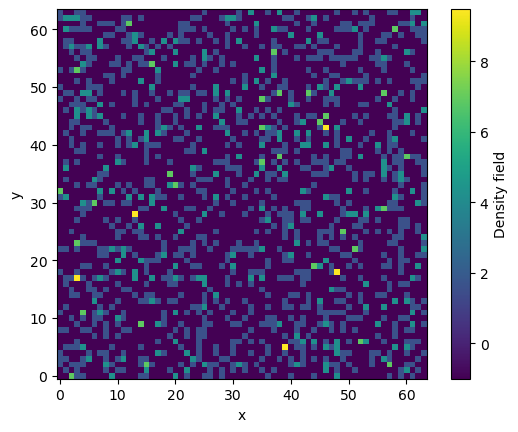

In [71]:
#definisco 

plt.imshow(density_field[:,:,0], origin='lower', interpolation='nearest')
#plt.imshow(density_field[:,:,0],origin='lower',cmap='virdis')
plt.colorbar(label='Density field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [72]:
delta_k= rfftn(density_field)/n_cells**3

In [73]:
#create the k grid
kf= 2* np.pi/L
H= L/n_cells
kN= np.pi/H

kx= fftfreq(n_cells, d= 1/n_cells)*kf
ky= fftfreq(n_cells, d= 1/n_cells)*kf
kz= rfftfreq(n_cells, d= 1/n_cells)*kf

KX,KY,KZ= np.meshgrid(kx,ky,kz)
KK= np.sqrt(KX**2 + KY**2 + KZ**2)



In [74]:
#pra posso calcolare lo spettro di potenza su griglia
pk_grid= delta_k * np.conjugate(delta_k)*volume


In [75]:
#binning
c=1
k_edges= np.arange(kf,kN, c*kf)


In [76]:
k_edges

array([0.00628319, 0.01256637, 0.01884956, 0.02513274, 0.03141593,
       0.03769911, 0.0439823 , 0.05026548, 0.05654867, 0.06283185,
       0.06911504, 0.07539822, 0.08168141, 0.08796459, 0.09424778,
       0.10053096, 0.10681415, 0.11309734, 0.11938052, 0.12566371,
       0.13194689, 0.13823008, 0.14451326, 0.15079645, 0.15707963,
       0.16336282, 0.169646  , 0.17592919, 0.18221237, 0.18849556,
       0.19477874])

In [77]:
#recupera il plot 
#plottiamo tutti i vettori d'onda linearizzati 
#voglio prendere tutti i punti che stanno qua dentro e faccio la media poi sposto lemdue linee rosse e ne faccio la media 

In [78]:
k_bins=0.5*(k_edges[1:]+k_edges[:-1])

In [79]:
print(KK.shape, pk_grid.shape)


(64, 64, 33) (64, 64, 33)


/home/asiat/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/asiat/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


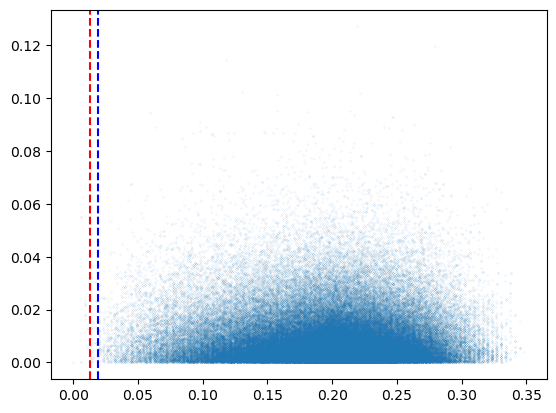

In [80]:
plt.plot(KK.flatten(),pk_grid.flatten(),'.',markersize=0.1)
plt.axvline(k_edges[1], color='red', linestyle='--', label='kF')
plt.axvline(k_edges[2], color='blue', linestyle='--', label='kN')


In [81]:
pk_averaged=np.zeros(k_bins.shape)
k_averaged=np.zeros(k_bins.shape)

for i in range(len(k_bins)):
    mask=(KK.flatten()>=k_edges[i]) & (KK.flatten()<k_edges[i+1])
    pk_averaged[i]=np.mean(pk_grid.flatten()[mask])
    k_averaged[i]=np.mean(KK.flatten()[mask])
    print("k_bins: ",k_bins[i])


k_bins:  0.00942477796076938
k_bins:  0.015707963267948967
k_bins:  0.02199114857512855
k_bins:  0.028274333882308142
k_bins:  0.034557519189487726
k_bins:  0.04084070449666731
k_bins:  0.047123889803846894
k_bins:  0.053407075111026485
k_bins:  0.059690260418206076
k_bins:  0.06597344572538566
k_bins:  0.07225663103256524
k_bins:  0.07853981633974483
k_bins:  0.08482300164692441
k_bins:  0.091106186954104
k_bins:  0.0973893722612836
k_bins:  0.10367255756846318
k_bins:  0.10995574287564276
k_bins:  0.11623892818282235
k_bins:  0.12252211349000194
k_bins:  0.12880529879718153
k_bins:  0.1350884841043611
k_bins:  0.1413716694115407
k_bins:  0.14765485471872028
k_bins:  0.15393804002589986
k_bins:  0.16022122533307945
k_bins:  0.16650441064025903
k_bins:  0.17278759594743864
k_bins:  0.17907078125461823
k_bins:  0.1853539665617978
k_bins:  0.1916371518689774


/tmp/ipykernel_3380/991570830.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  pk_averaged[i]=np.mean(pk_grid.flatten()[mask])


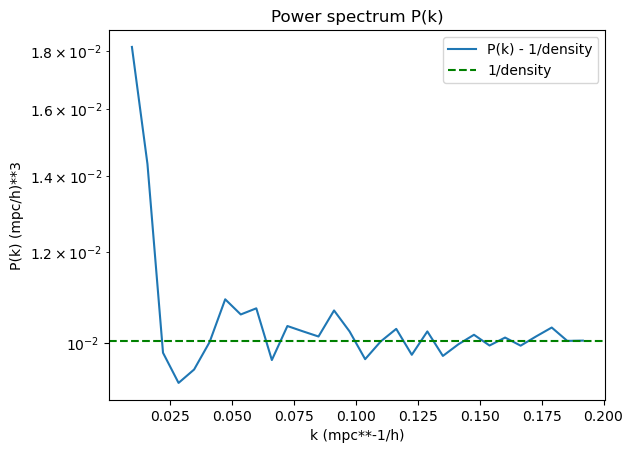

In [82]:
plt.semilogy(k_bins,pk_averaged,label='P(k) - 1/density')
plt.axhline(1./density, color='green', linestyle='--', label='1/density')
plt.xlabel('k (mpc**-1/h)')
plt.ylabel('P(k) (mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()

# %% [markdown]
# è misura della pk della sorgente; c'è shot noise sparso e poi segnale intrinseco che è power law, le fluttuazioni che vedo sono oscillazioni, non flutt statistiche. si dovrebbe vedere anche prima del picco a sx, la salita